# NYC Proxy Weather Nowcaster — Training Data EDA

Downloads and merges all tabular training sources, then shows hourly distributions and correlations.

**Sources:** Open-Meteo (ground truth labels), NYISO grid load, MTA daily ridership, NYC 311 complaints  
**Date range:** 2022-02-01 → 2024-12-31

**Targets**
- `precip`: `clear` | `cloudy` | `rainy` | `snowy`
- `temp`: `cold` (<4.44°C / 40°F) | `temperate` | `hot` (>26.67°C / 80°F)

In [ ]:
import pandas as pd
import numpy as np
import requests
import requests_cache
import io
import zipfile
import warnings
from retry_requests import retry

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────
NYC_LAT, NYC_LON = 40.7128, -74.0060
COLD_C, HOT_C    = 4.44, 26.67        # 40°F, 80°F
PRECIP_MM        = 1.0

CONDITION_ORDER = ["clear", "cloudy", "rainy", "snowy"]
COLORS          = {"clear": "#F4C842", "cloudy": "#8FA8C8", "rainy": "#3A7FC1", "snowy": "#B8D4E8"}

TEMP_ORDER   = ["cold", "temperate", "hot"]
TEMP_COLORS  = {"cold": "#3A7FC1", "temperate": "#7FC47F", "hot": "#E8613A"}

# ── Known publication lags and rolling window ─────────────────────────────────
MTA_LAG    = 3   # days: MTA ridership publication lag
LAG_311    = 1   # days: 311 complaints publication lag
LAG_WINDOW = 1   # X: rolling sum window — feature = sum(t-L, ..., t-L-X+1)
                 #   X=1 → single lagged value; increase to smooth over more days

WMO = {
    0:  ("Clear sky",              "clear"),
    1:  ("Mainly clear",           "clear"),
    2:  ("Partly cloudy",          "cloudy"),
    3:  ("Overcast",               "cloudy"),
    45: ("Fog",                    "cloudy"),
    48: ("Icy fog",                "cloudy"),
    51: ("Light drizzle",          "rainy"),  53: ("Moderate drizzle",  "rainy"),
    55: ("Dense drizzle",          "rainy"),  56: ("Freezing drizzle",  "rainy"),
    57: ("Heavy freezing drizzle", "rainy"),
    61: ("Slight rain",            "rainy"),  63: ("Moderate rain",     "rainy"),
    65: ("Heavy rain",             "rainy"),  66: ("Freezing rain",     "rainy"),
    67: ("Heavy freezing rain",    "rainy"),
    71: ("Slight snow",            "snowy"),  73: ("Moderate snow",     "snowy"),
    75: ("Heavy snow",             "snowy"),  77: ("Snow grains",       "snowy"),
    80: ("Slight showers",         "rainy"),  81: ("Moderate showers",  "rainy"),
    82: ("Violent showers",        "rainy"),  85: ("Snow showers",      "snowy"),
    86: ("Heavy snow showers",     "snowy"),
    95: ("Thunderstorm",           "rainy"),  96: ("Thunderstorm/hail", "rainy"),
    99: ("Thunderstorm/hail",      "rainy"),
}

## 1. Fetch Functions

In [2]:
def fetch_openmeteo(start: str, end: str) -> pd.DataFrame:
    """Hourly weather from Open-Meteo ERA5 archive. Produces precip and temp target labels."""
    session = retry(
        requests_cache.CachedSession(".openmeteo_cache", expire_after=86400),
        retries=5, backoff_factor=0.3,
    )
    r = session.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": NYC_LAT, "longitude": NYC_LON,
        "start_date": start, "end_date": end,
        "hourly": ["temperature_2m", "apparent_temperature", "precipitation",
                   "snowfall", "weathercode", "cloudcover",
                   "windspeed_10m", "relativehumidity_2m", "visibility"],
        "timezone": "America/New_York",
    })
    r.raise_for_status()
    h = r.json()["hourly"]

    df = pd.DataFrame({
        "temperature_c":    h["temperature_2m"],
        "apparent_temp_c":  h["apparent_temperature"],
        "precipitation_mm": h["precipitation"],
        "snowfall_cm":      h["snowfall"],
        "weathercode":      h["weathercode"],
        "cloudcover_pct":   h["cloudcover"],
        "windspeed_kmh":    h["windspeed_10m"],
        "humidity_pct":     h["relativehumidity_2m"],
        "visibility_m":     h["visibility"],
    }, index=pd.to_datetime(h["time"]))
    df.index.name = "timestamp"

    df["precip"] = pd.Categorical(
        df["weathercode"].map(lambda c: WMO.get(c, (None, "cloudy"))[1]),
        categories=CONDITION_ORDER, ordered=True,
    )
    df["temp"] = pd.Categorical(
        df["temperature_c"].apply(
            lambda t: "cold" if t < COLD_C else "hot" if t > HOT_C else "temperate"
        ),
        categories=TEMP_ORDER, ordered=True,
    )
    df["precip_int"] = df["precip"].cat.codes
    df["temp_int"]   = df["temp"].cat.codes
    return df

In [3]:
def fetch_nyiso_month(year: int, month: int) -> pd.Series:
    url = f"https://mis.nyiso.com/public/csv/pal/{year}{month:02d}01pal_csv.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        frames = [pd.read_csv(z.open(name)) for name in z.namelist()]
    raw = pd.concat(frames, ignore_index=True)
    nyc = raw[raw["Name"].str.strip() == "N.Y.C."].copy()
    nyc["timestamp"] = (
        pd.to_datetime(nyc["Time Stamp"]) - pd.Timedelta(minutes=5)
    ).dt.floor("h")
    return nyc.groupby("timestamp")["Load"].mean().rename("nyiso_load_mw")


def fetch_nyiso(start: str, end: str) -> pd.Series:
    """NYC Zone J hourly load (MW). Strongest tabular proxy signal."""
    parts = []
    for p in pd.period_range(start, end, freq="M"):
        print(f"  NYISO {p.year}-{p.month:02d}", end="\r")
        try:
            parts.append(fetch_nyiso_month(p.year, p.month))
        except Exception as e:
            print(f"  WARNING NYISO {p.year}-{p.month:02d}: {e}")
    print()
    return pd.concat(parts).sort_index()

In [4]:
def fetch_mta(start: str, end: str) -> pd.DataFrame:
    """MTA daily ridership — data.ny.gov dataset sayj-mze2 (replaces deprecated vxuj-8kew).

    New schema is long-format: one row per (date, mode). We pivot Subway and Bus.
    """
    session = requests_cache.CachedSession(".mta_cache", expire_after=86400)
    params = {
        "$where":  f"date >= '{start}T00:00:00' and date <= '{end}T23:59:59'",
        "$order":  "date ASC",
        "$limit":  "10000",
    }
    r = session.get("https://data.ny.gov/resource/sayj-mze2.json", params=params, timeout=60)
    r.raise_for_status()

    raw = pd.DataFrame(r.json())
    if raw.empty:
        print("  WARNING: MTA returned empty response")
        return pd.DataFrame()

    raw["date"]  = pd.to_datetime(raw["date"]).dt.normalize()
    raw["count"] = pd.to_numeric(raw["count"], errors="coerce")

    pivot = (
        raw[raw["mode"].isin(["Subway", "Bus"])]
        .pivot_table(index="date", columns="mode", values="count", aggfunc="sum")
        .rename(columns={"Subway": "mta_subway", "Bus": "mta_bus"})
    )
    print(f"  MTA: {len(pivot)} days, columns: {list(pivot.columns)}")
    pivot.index.name = "date"
    return pivot

In [5]:
def fetch_311(start: str, end: str) -> pd.DataFrame:
    """NYC 311 daily counts for weather-correlated complaint types."""
    session = requests_cache.CachedSession(".311_cache", expire_after=86400)
    types = ["HEAT/HOT WATER", "Street Flooding", "Flooded Basement", "Snow"]
    type_list = ", ".join(f"'{t}'" for t in types)

    params = {
        "$select": "date_trunc_ymd(created_date) as date, complaint_type, count(*) as cnt",
        "$group":  "date_trunc_ymd(created_date), complaint_type",
        "$where":  (
            f"complaint_type in ({type_list})"
            f" and created_date >= '{start}T00:00:00'"
            f" and created_date <= '{end}T23:59:59'"
        ),
        "$limit": "50000",
    }
    r = session.get(
        "https://data.cityofnewyork.us/resource/erm2-nwe9.json",
        params=params, timeout=120,
    )
    r.raise_for_status()

    raw = pd.DataFrame(r.json())
    if raw.empty:
        print("  WARNING: 311 returned empty response")
        return pd.DataFrame()

    raw["date"] = pd.to_datetime(raw["date"]).dt.normalize()
    raw["cnt"]  = pd.to_numeric(raw["cnt"], errors="coerce").fillna(0).astype(int)

    pivot = (
        raw.pivot_table(index="date", columns="complaint_type",
                        values="cnt", aggfunc="sum", fill_value=0)
           .rename(columns={
               "HEAT/HOT WATER":   "311_heat",
               "Street Flooding":  "311_flood_street",
               "Flooded Basement": "311_flood_basement",
               "Snow":             "311_snow",
           })
    )
    # Merge flood sub-types into one column
    flood_cols = [c for c in pivot.columns if c.startswith("311_flood_")]
    if flood_cols:
        pivot["311_flood"] = pivot[flood_cols].sum(axis=1)
        pivot = pivot.drop(columns=flood_cols)

    print(f"  311: {len(pivot)} days, columns: {list(pivot.columns)}")
    pivot.index.name = "date"
    return pivot

## 2. Daily Aggregation & Merge

In [ ]:
def make_daily(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate hourly weather+NYISO frame to daily labels and features."""
    daily = df.groupby(df.index.date).agg(
        temp_mean_c       = ("temperature_c",    "mean"),
        temp_min_c        = ("temperature_c",    "min"),
        temp_max_c        = ("temperature_c",    "max"),
        precip_total_mm   = ("precipitation_mm", "sum"),
        snowfall_total_cm = ("snowfall_cm",      "sum"),
        cloudcover_mean   = ("cloudcover_pct",   "mean"),
        windspeed_max     = ("windspeed_kmh",    "max"),
        nyiso_mean_mw     = ("nyiso_load_mw",    "mean"),
        nyiso_max_mw      = ("nyiso_load_mw",    "max"),
    )
    daily.index = pd.to_datetime(daily.index)
    daily.index.name = "date"

    daily["precip"] = pd.Categorical(
        daily.apply(lambda r: (
            "snowy"  if r["snowfall_total_cm"] > 0 else
            "rainy"  if r["precip_total_mm"] >= PRECIP_MM else
            "cloudy" if r["cloudcover_mean"] >= 60 else
            "clear"
        ), axis=1),
        categories=CONDITION_ORDER, ordered=True,
    )
    daily["temp"] = pd.Categorical(
        daily["temp_mean_c"].apply(
            lambda t: "cold" if t < COLD_C else "hot" if t > HOT_C else "temperate"
        ),
        categories=TEMP_ORDER, ordered=True,
    )
    daily["precip_int"] = daily["precip"].cat.codes
    daily["temp_int"]   = daily["temp"].cat.codes
    return daily


def _lag_feature(df: pd.DataFrame, lag: int, window: int) -> pd.DataFrame:
    """Shift by known publication lag then sum over a rolling window of size X.

    feature[t] = sum(df[t-lag], df[t-lag-1], ..., df[t-lag-X+1])
    With window=1 this is just the single value at t-lag.
    """
    return df.shift(lag).rolling(window, min_periods=1).sum()


def merge_all(start: str = "2022-02-01", end: str = "2024-12-31"):
    """Returns (hourly, daily) DataFrames with all tabular sources merged.

    Daily-cadence sources (MTA, 311) are shifted by their known publication lag
    and summed over a rolling window of LAG_WINDOW days before joining. The
    resulting daily feature is then forward-filled onto the hourly frame.
    """
    print("Fetching Open-Meteo...")
    hourly = fetch_openmeteo(start, end)

    print("Fetching NYISO...")
    nyiso  = fetch_nyiso(start, end)
    hourly = hourly.join(nyiso, how="left")

    print("Aggregating to daily...")
    daily = make_daily(hourly)

    print("Fetching MTA ridership...")
    mta = fetch_mta(start, end)
    if not mta.empty:
        mta_feat = _lag_feature(mta, MTA_LAG, LAG_WINDOW)
        daily  = daily.join(mta_feat, how="left")
        hourly = hourly.join(mta_feat.reindex(hourly.index, method="ffill"), how="left")

    print("Fetching 311 complaints...")
    complaints = fetch_311(start, end)
    if not complaints.empty:
        comp_feat = _lag_feature(complaints, LAG_311, LAG_WINDOW)
        daily  = daily.join(comp_feat, how="left")
        hourly = hourly.join(comp_feat.reindex(hourly.index, method="ffill"), how="left")
        for col in daily.filter(like="311_").columns:
            daily[col]  = daily[col].fillna(0)
            hourly[col] = hourly[col].fillna(0)

    print(f"\nhourly: {len(hourly):,} rows  |  {hourly.shape[1]} columns")
    print(f"daily:  {len(daily):,} rows  |  {daily.shape[1]} columns")
    print(f"range:  {daily.index[0].date()} -> {daily.index[-1].date()}")
    print(f"lags:   MTA={MTA_LAG}d, 311={LAG_311}d, window={LAG_WINDOW}d")
    return hourly, daily

## 3. Build Dataset

In [7]:
hourly, daily = merge_all()

Fetching Open-Meteo...
Fetching NYISO...
  NYISO 2024-12
Aggregating to daily...
Fetching MTA ridership...
  MTA: 1065 days, columns: ['mta_bus', 'mta_subway']
Fetching 311 complaints...
  311: 1060 days, columns: ['311_heat']

hourly: 26,070 rows  |  17 columns
daily:  1,065 rows  |  16 columns
range:  2022-02-01 -> 2024-12-31


## 4. Dataset Overview (Hourly)

In [8]:
cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow", "precip", "temp"]
        if c in hourly.columns]
hourly[cols].head(10)

,nyiso_load_mw,mta_subway,mta_bus,311_heat,precip,temp
timestamp,,,,,,
2022-02-01 00:00:00,5343.660369,2635083,1127084,1629,clear,cold
2022-02-01 01:00:00,5146.769207,2635083,1127084,1629,clear,cold
2022-02-01 02:00:00,5023.546925,2635083,1127084,1629,clear,cold
2022-02-01 03:00:00,4975.408675,2635083,1127084,1629,clear,cold
2022-02-01 04:00:00,4996.359783,2635083,1127084,1629,clear,cold
2022-02-01 05:00:00,5199.784933,2635083,1127084,1629,clear,cold
2022-02-01 06:00:00,5560.732064,2635083,1127084,1629,clear,cold
2022-02-01 07:00:00,5985.080617,2635083,1127084,1629,clear,cold
2022-02-01 08:00:00,6275.530583,2635083,1127084,1629,clear,cold


In [9]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow"]
              if c in hourly.columns]
hourly[proxy_cols + ["precip_int", "temp_int"]].describe().round(2)

,nyiso_load_mw,mta_subway,mta_bus,311_heat,precip_int,temp_int
count,26070.00,26070.00,26070.00,26070.00,26070.00,26070.00
mean,5604.39,3092431.68,1154573.51,654.77,0.72,0.86
std,1152.16,786656.88,308464.21,716.05,0.74,0.51
min,3708.70,1008452.00,321245.00,40.00,0.00,0.00
25%,4785.18,2365464.00,859295.00,115.00,0.00,1.00
50%,5458.58,3297927.00,1272485.00,380.00,1.00,1.00
75%,6123.58,3707751.00,1403811.00,977.00,1.00,1.00
max,10829.66,4527892.00,1590666.00,5696.00,3.00,2.00


In [10]:
print(f"Hourly shape: {hourly.shape}")
miss = hourly.isnull().sum()
miss = miss[miss > 0].rename("missing").to_frame()
miss["pct"] = (miss["missing"] / len(hourly) * 100).round(1)
if miss.empty:
    print("No missing values")
else:
    display(miss)

Hourly shape: (26070, 17)


,missing,pct
visibility_m,26070,100.0


## 5. Precipitation Target

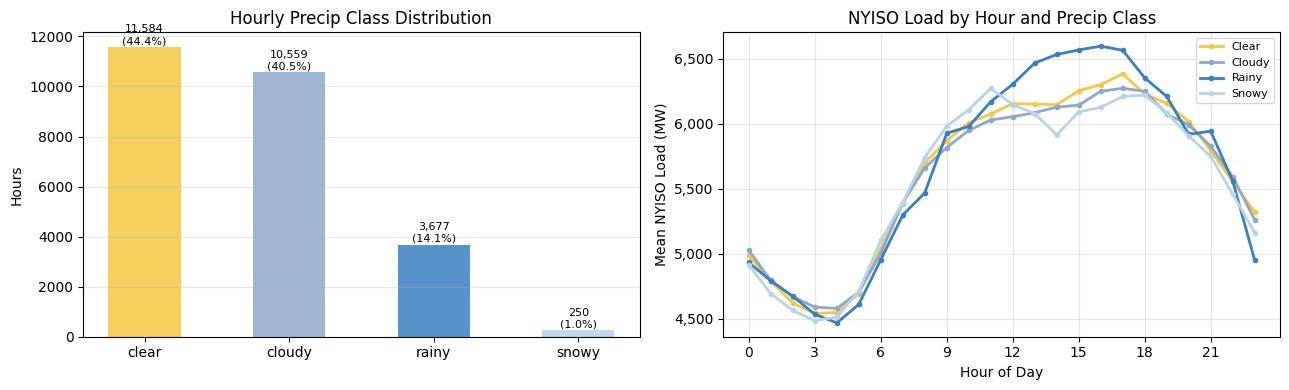

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: hourly class counts
counts = hourly["precip"].value_counts().reindex(CONDITION_ORDER)
bars = ax1.bar(CONDITION_ORDER, counts.values, color=[COLORS[c] for c in CONDITION_ORDER],
               alpha=0.85, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = 100 * val / len(hourly)
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("Hours")
ax1.set_title("Hourly Precip Class Distribution")
ax1.grid(axis="y", alpha=0.3)

# Right: NYISO load profile by precip class
df_h = hourly.dropna(subset=["nyiso_load_mw"]).copy()
df_h["hour"] = df_h.index.hour
grouped = df_h.groupby(["hour", "precip"], observed=True)["nyiso_load_mw"].mean().reset_index()
for cond in CONDITION_ORDER:
    sub = grouped[grouped["precip"] == cond]
    ax2.plot(sub["hour"], sub["nyiso_load_mw"], label=cond.capitalize(),
             color=COLORS[cond], linewidth=2, marker="o", markersize=3)
ax2.set_xticks(range(0, 24, 3))
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Mean NYISO Load (MW)")
ax2.set_title("NYISO Load by Hour and Precip Class")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

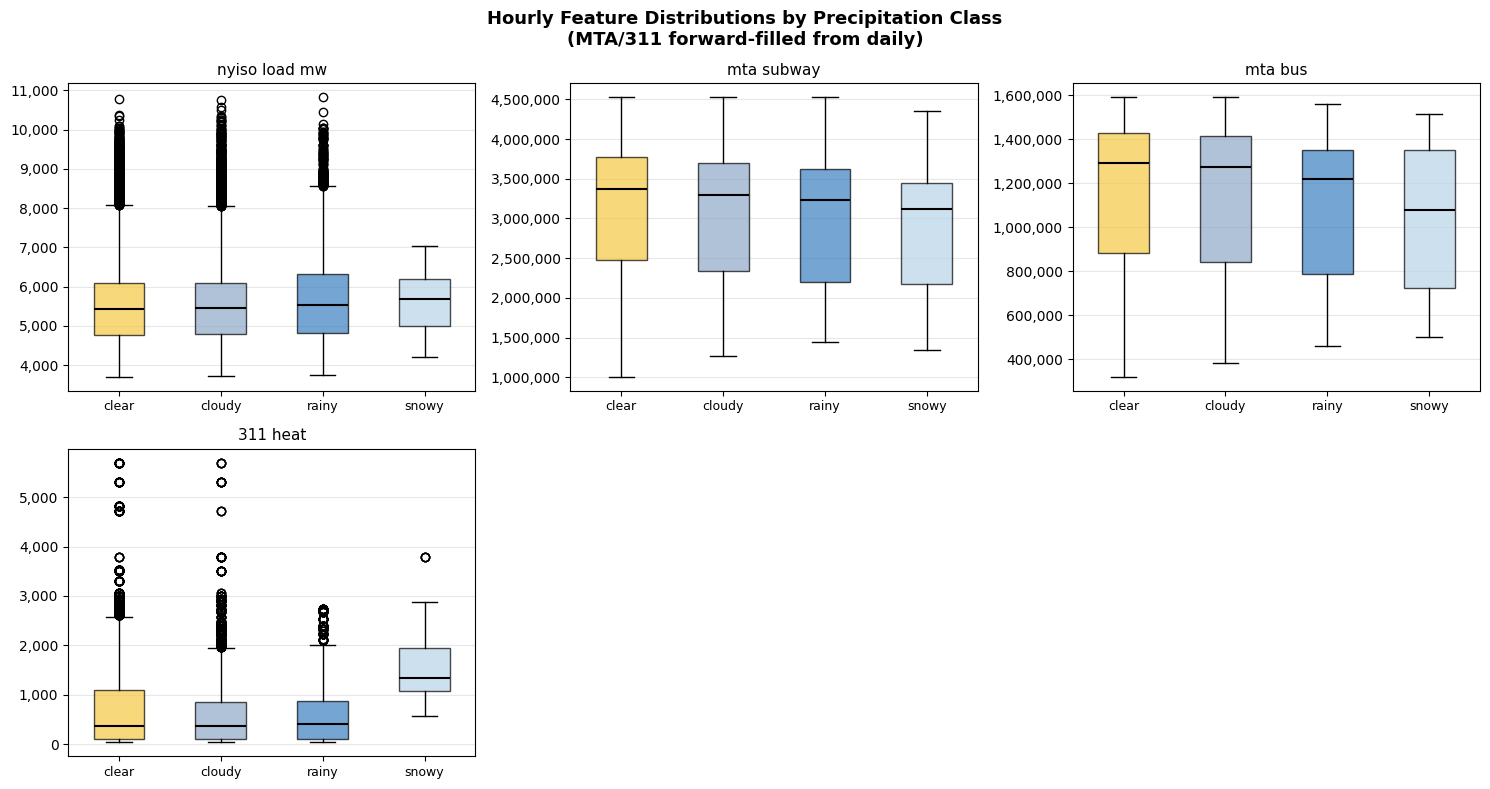

In [12]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow"]
              if c in hourly.columns]

n_cols = min(3, len(proxy_cols))
n_rows = (len(proxy_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, proxy_cols):
    groups = [hourly.loc[hourly["precip"] == c, col].dropna().values for c in CONDITION_ORDER]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={"linewidth": 1.5, "color": "black"})
    for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
        patch.set_facecolor(COLORS[cond])
        patch.set_alpha(0.7)
    ax.set_xticklabels(CONDITION_ORDER, fontsize=9)
    ax.set_title(col.replace("_", " "), fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(proxy_cols):]:
    ax.set_visible(False)

fig.suptitle("Hourly Feature Distributions by Precipitation Class\n(MTA/311 forward-filled from daily)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Temperature Target

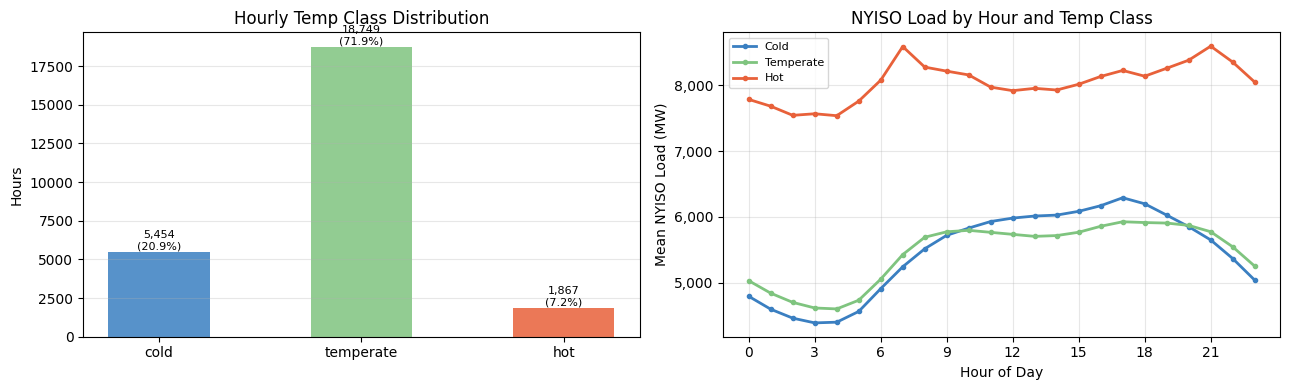

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: hourly class counts
counts = hourly["temp"].value_counts().reindex(TEMP_ORDER)
bars = ax1.bar(TEMP_ORDER, counts.values, color=[TEMP_COLORS[c] for c in TEMP_ORDER],
               alpha=0.85, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = 100 * val / len(hourly)
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("Hours")
ax1.set_title("Hourly Temp Class Distribution")
ax1.grid(axis="y", alpha=0.3)

# Right: NYISO load profile by temp class
df_h = hourly.dropna(subset=["nyiso_load_mw"]).copy()
df_h["hour"] = df_h.index.hour
grouped = df_h.groupby(["hour", "temp"], observed=True)["nyiso_load_mw"].mean().reset_index()
for tc in TEMP_ORDER:
    sub = grouped[grouped["temp"] == tc]
    ax2.plot(sub["hour"], sub["nyiso_load_mw"], label=tc.capitalize(),
             color=TEMP_COLORS[tc], linewidth=2, marker="o", markersize=3)
ax2.set_xticks(range(0, 24, 3))
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Mean NYISO Load (MW)")
ax2.set_title("NYISO Load by Hour and Temp Class")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

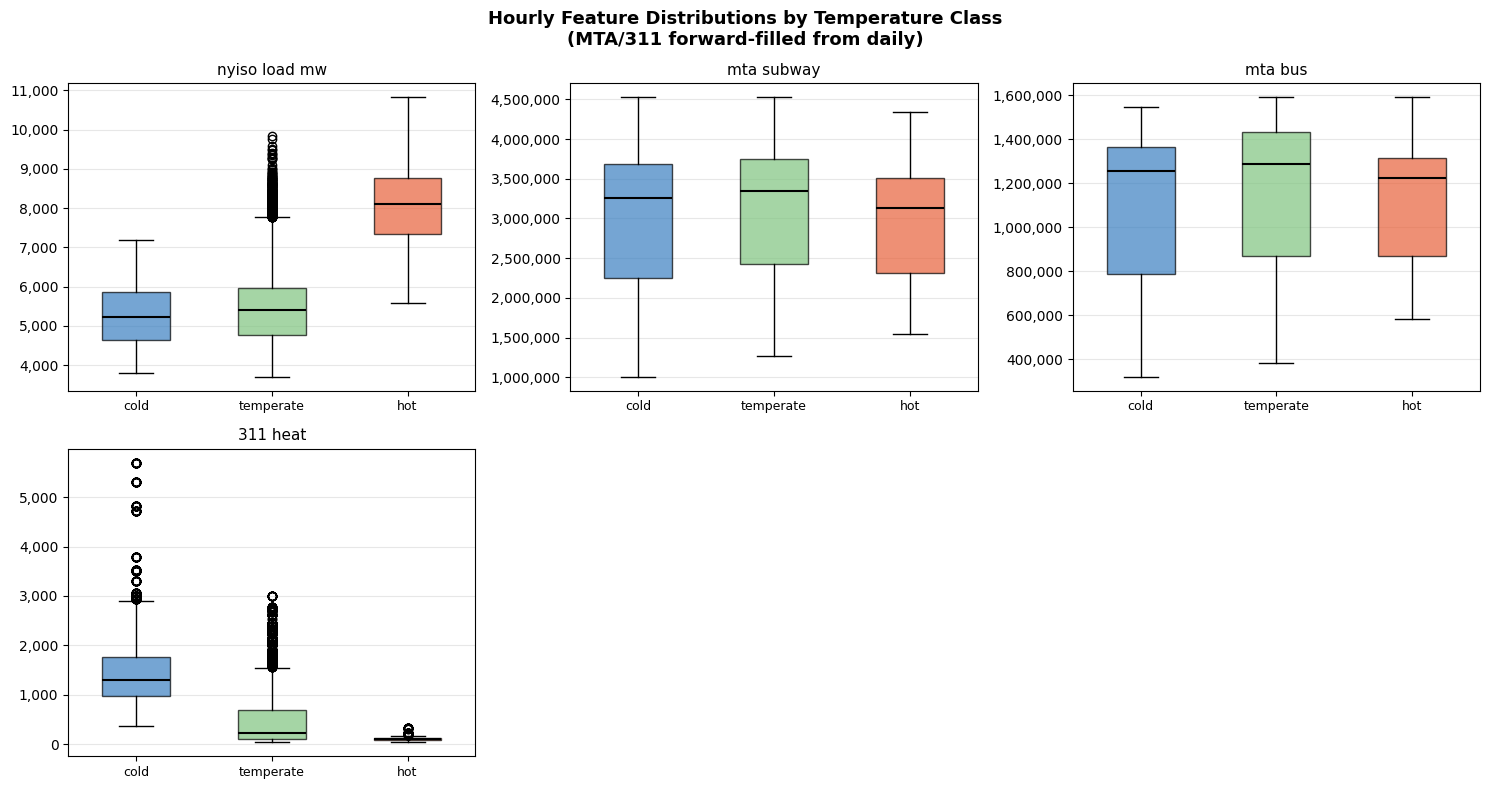

In [14]:
proxy_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow"]
              if c in hourly.columns]

n_cols = min(3, len(proxy_cols))
n_rows = (len(proxy_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, proxy_cols):
    groups = [hourly.loc[hourly["temp"] == tc, col].dropna().values for tc in TEMP_ORDER]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={"linewidth": 1.5, "color": "black"})
    for patch, tc in zip(bp["boxes"], TEMP_ORDER):
        patch.set_facecolor(TEMP_COLORS[tc])
        patch.set_alpha(0.7)
    ax.set_xticklabels(TEMP_ORDER, fontsize=9)
    ax.set_title(col.replace("_", " "), fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(proxy_cols):]:
    ax.set_visible(False)

fig.suptitle("Hourly Feature Distributions by Temperature Class\n(MTA/311 forward-filled from daily)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Hourly Correlations

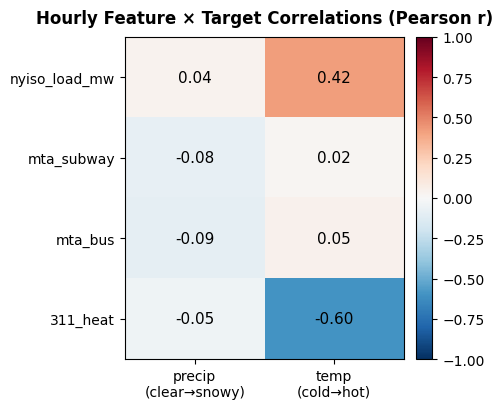

In [15]:
target_cols  = ["precip_int", "temp_int"]
feature_cols = [c for c in ["nyiso_load_mw", "mta_subway", "mta_bus", "311_heat", "311_flood", "311_snow"]
                if c in hourly.columns]

corr_df = hourly[feature_cols + target_cols].dropna()
corr = pd.DataFrame({t: corr_df[feature_cols].corrwith(corr_df[t]) for t in target_cols})

fig, ax = plt.subplots(figsize=(5, len(feature_cols) * 0.8 + 1))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(2))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(["precip\n(clear→snowy)", "temp\n(cold→hot)"], fontsize=10)
ax.set_yticklabels(feature_cols, fontsize=10)

for i in range(len(feature_cols)):
    for j in range(2):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
ax.set_title("Hourly Feature × Target Correlations (Pearson r)", fontsize=12, fontweight="bold", pad=10)
fig.tight_layout()
plt.show()